In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [5]:
df = pd.read_csv("house_rent_training_data.csv")
print("Dataset Shape:", df.shape)
print(df.head())



Dataset Shape: (1500, 6)
   area_sqft  bedrooms  bathrooms  property_age  distance_city_km   rent
0        641         3          2            21              20.9  26426
1       2114         2          1            16              15.3  38528
2       1857         2          1            30               6.9  31510
3       1394         2          1            23              18.9  22385
4       1381         3          2             0               3.0  43932


In [6]:
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_sqft         1500 non-null   int64  
 1   bedrooms          1500 non-null   int64  
 2   bathrooms         1500 non-null   int64  
 3   property_age      1500 non-null   int64  
 4   distance_city_km  1500 non-null   float64
 5   rent              1500 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 70.4 KB
None

Missing Values:
area_sqft           0
bedrooms            0
bathrooms           0
property_age        0
distance_city_km    0
rent                0
dtype: int64


In [8]:
X = df[[
    "area_sqft",
    "bedrooms",
    "bathrooms",
    "property_age",
    "distance_city_km"
]]

y = df["rent"]


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (1200, 5)
Testing Data: (300, 5)


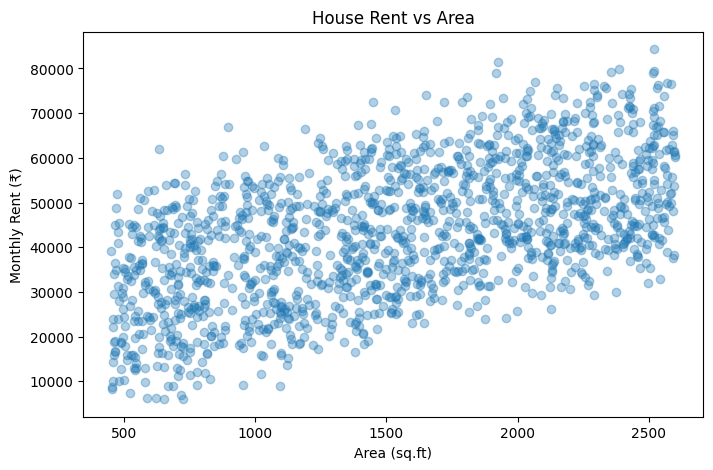

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["area_sqft"],
        df["rent"],
            alpha=0.35
            )
plt.xlabel("Area (sq.ft)")
plt.ylabel("Monthly Rent (₹)")
plt.title("House Rent vs Area")
plt.show()



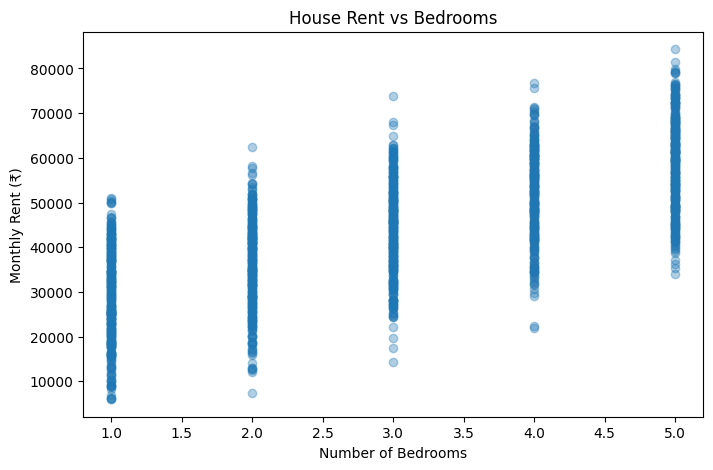

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["bedrooms"],
        df["rent"],
            alpha=0.35
            )
plt.xlabel("Number of Bedrooms")
plt.ylabel("Monthly Rent (₹)")
plt.title("House Rent vs Bedrooms")
plt.show()


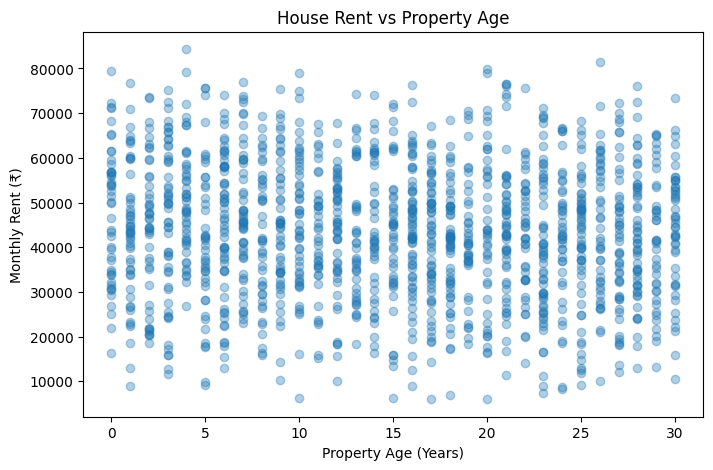

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["property_age"],
        df["rent"],
            alpha=0.35
            )
plt.xlabel("Property Age (Years)")
plt.ylabel("Monthly Rent (₹)")
plt.title("House Rent vs Property Age")
plt.show()


In [15]:
model = RandomForestRegressor(
      n_estimators=200,
          random_state=42,
              min_samples_leaf=2
              )

model.fit(X_train, y_train)
print("Model Training Completed!")



Model Training Completed!


In [16]:
y_pred = model.predict(X_test)
print("Predicted House Rent:")
print(y_pred[:10])



Predicted House Rent:
[75531.2622381  72256.70948214 62995.39681349 37443.90726587
 65510.11596032 62961.57723611 48675.88239881 62370.98114683
 45709.99399405 52593.13482937]


In [17]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
    )
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 :", r2)


MAE : 4631.41737000601
RMSE: 5864.975224757434
R2 : 0.8551572729779298


In [19]:
sample = pd.DataFrame([
    {
        "area_sqft": 1200,
        "bedrooms": 2,
        "bathrooms": 2,
        "property_age": 5,
        "distance_city_km": 8
    }
])

prediction = model.predict(sample)[0]

print("Predicted House Rent:",
      round(prediction, 2))

Predicted House Rent: 31284.03
